In [1]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
connection_url = URL.create(
    drivername="postgresql+psycopg2",
    username="postgres",
    password="@mami1515",
    host="localhost",
    port=5432,
    database="ecommerce"
)
engine = create_engine(connection_url)
print("✅ Connected to PostgreSQL!")

✅ Connected to PostgreSQL!


In [2]:
df_min_time = pd.read_sql_query('''
    SELECT "Year_Month", ROUND(SUM("Total Price")::numeric, 2) AS revenue 
    FROM ecommerce GROUP BY "Year_Month" ORDER BY "Year_Month" ASC;
''', engine)
df_min_time

,Year_Month,revenue
0,April 2011,469200.36
1,August 2011,645343.90
2,December 2010,572713.89
3,December 2011,518192.79
4,February 2011,447137.35
5,January 2011,569445.04
6,July 2011,600091.01
7,June 2011,661213.69
8,March 2011,595500.76
9,May 2011,678594.56


In [3]:
df_max_time = pd.read_sql_query('''
    SELECT "Year_Month", ROUND(SUM("Total Price")::numeric, 2) AS revenue 
    FROM ecommerce GROUP BY "Year_Month" ORDER BY "Year_Month" desc;
''', engine)
df_max_time

,Year_Month,revenue
0,September 2011,952838.38
1,October 2011,1039318.79
2,November 2011,1161817.38
3,May 2011,678594.56
4,March 2011,595500.76
5,June 2011,661213.69
6,July 2011,600091.01
7,January 2011,569445.04
8,February 2011,447137.35
9,December 2011,518192.79


In [4]:
df_min_hours = pd.read_sql_query('''
    SELECT substring("Day_Time", 4, 2) AS peak_hour, ROUND(SUM("Total Price")::numeric, 2) AS total_income 
    FROM ecommerce GROUP BY peak_hour ORDER BY peak_hour ASC;
''', engine)
df_min_hours

,peak_hour,total_income
0,06,4.25
1,07,31059.21
2,08,282115.63
3,09,842605.17
4,10,1261192.57
5,11,1104558.75
6,12,1378571.48
7,13,1173264.75
8,14,995629.37
9,15,966191.75


In [5]:
df_max_hours = pd.read_sql_query('''
    SELECT substring("Day_Time", 4, 2) AS peak_hour, ROUND(SUM("Total Price")::numeric, 2) AS total_income 
    FROM ecommerce GROUP BY peak_hour ORDER BY peak_hour desc
                                 limit 5;
''', engine)
df_max_hours

,peak_hour,total_income
0,20,18932.76
1,19,49028.46
2,18,104954.43
3,17,234413.52
4,16,468885.80


In [6]:
df_max_products = pd.read_sql_query('''
    SELECT "Description", SUM("Quantity") AS quantity_sold 
    FROM ecommerce GROUP BY "Description" ORDER BY quantity_sold DESC LIMIT 5;
''', engine)
df_max_products

,Description,quantity_sold
0,"paper craft , little birdie",80995.0
1,medium ceramic top storage jar,77916.0
2,world war 2 gliders asstd designs,54415.0
3,jumbo bag red retrospot,46181.0
4,white hanging heart t-light holder,36725.0


In [7]:

df_max_country = pd.read_sql_query('''
    SELECT "Country", ROUND(SUM("Total Price")::numeric, 2) AS revenue 
    FROM ecommerce GROUP BY "Country" ORDER BY revenue DESC LIMIT 5;
''', engine)
df_max_country

,Country,revenue
0,United Kingdom,7308391.55
1,Netherlands,285446.34
2,EIRE,265545.90
3,Germany,228867.14
4,France,209024.05


In [8]:
df_min_products = pd.read_sql_query('''
    SELECT "Description", SUM("Quantity") AS quantity_sold 
    FROM ecommerce GROUP BY "Description" ORDER BY quantity_sold asc LIMIT 5;
''', engine)
df_min_products

,Description,quantity_sold
0,black drop earrings w long beads,1.0
1,baroque butterfly earrings crystal,1.0
2,white rosebud pearl earrings,1.0
3,midnight blue crystal drop earrings,1.0
4,funky monkey mug,1.0


In [9]:

df_min_country = pd.read_sql_query('''
    SELECT "Country", ROUND(SUM("Total Price")::numeric, 2) AS revenue 
    FROM ecommerce GROUP BY "Country" ORDER BY revenue asc LIMIT 5;
''', engine)
df_min_country

,Country,revenue
0,Saudi Arabia,145.92
1,Bahrain,548.40
2,Czech Republic,826.74
3,RSA,1002.31
4,Brazil,1143.60


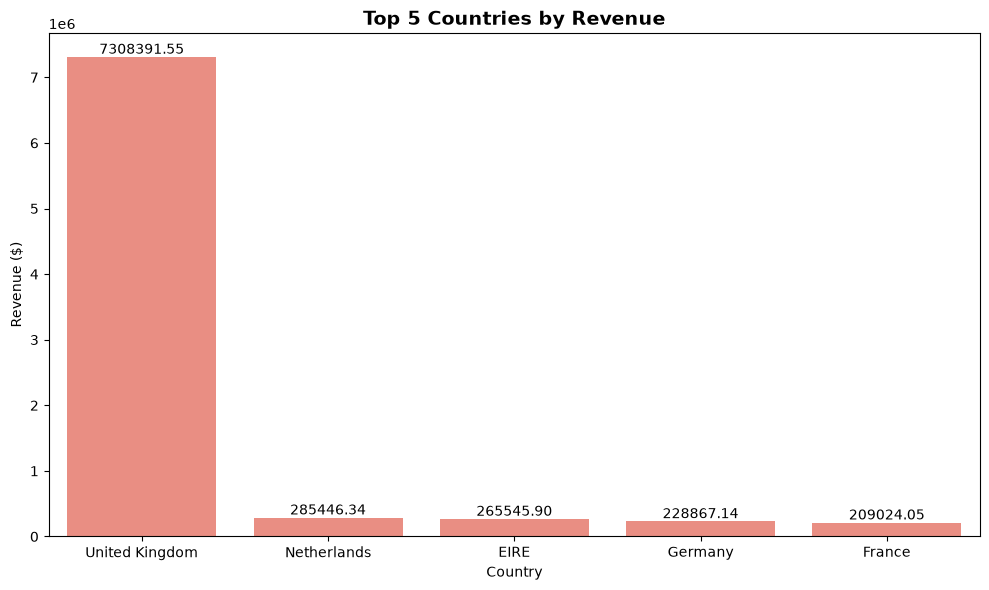

In [ ]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=df_max_country,
    x="Country",
    y="revenue",
    color = "salmon"
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.title(
    "Top 5 Countries by Revenue",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Country")
plt.ylabel("Revenue ($)")
plt.savefig("top_countries.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

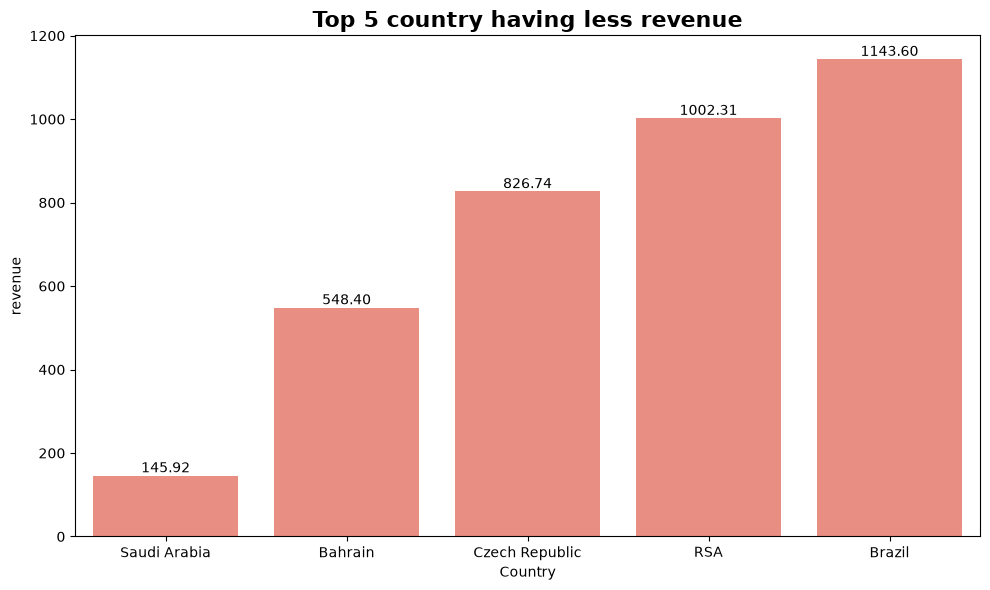

In [11]:
plt.figure(figsize=(10,6))
ax = sns.barplot(
    data= df_min_country,
    x = "Country",
    y = "revenue",
    color = "salmon"

)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.title(
    "Top 5 country having less revenue",
    fontsize = 16,
    fontweight = "bold"
)
plt.xlabel="Country"
plt.ylable="Revenue($)"
plt.tight_layout()
plt.show()






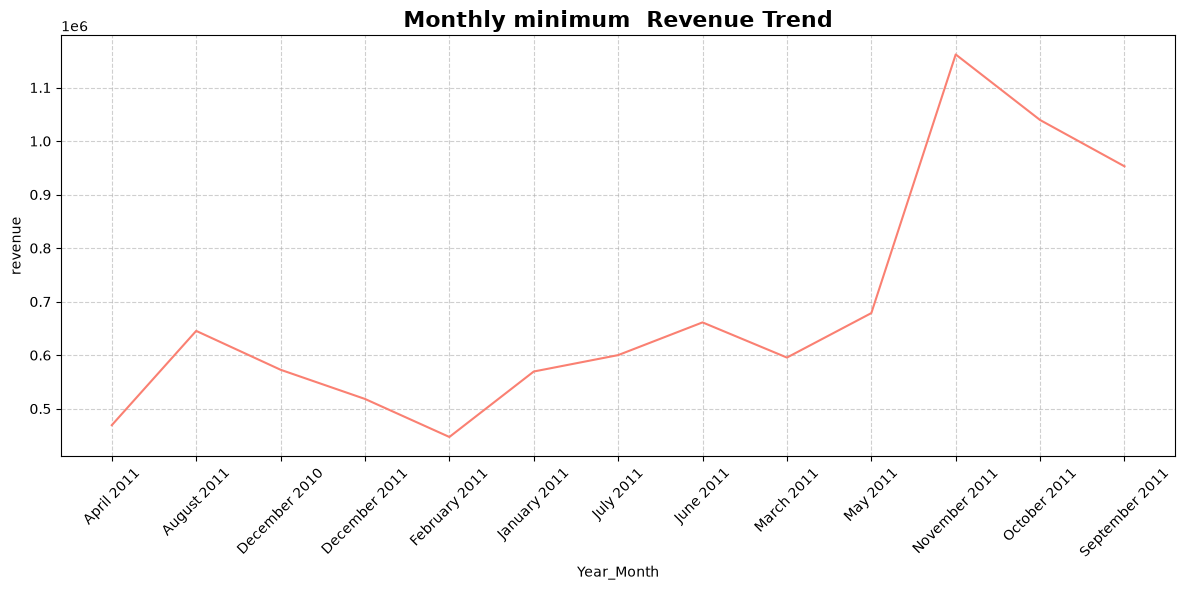

In [12]:
plt.figure(figsize=(12,6))

ax = sns.lineplot(
    data=df_min_time,
    x="Year_Month",
    y="revenue",
    color = "salmon"
   
)

plt.title(
    "Monthly minimum  Revenue Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel= ("Year")
plt.ylabel=("Revenue ($)")

plt.xticks(rotation=45)

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

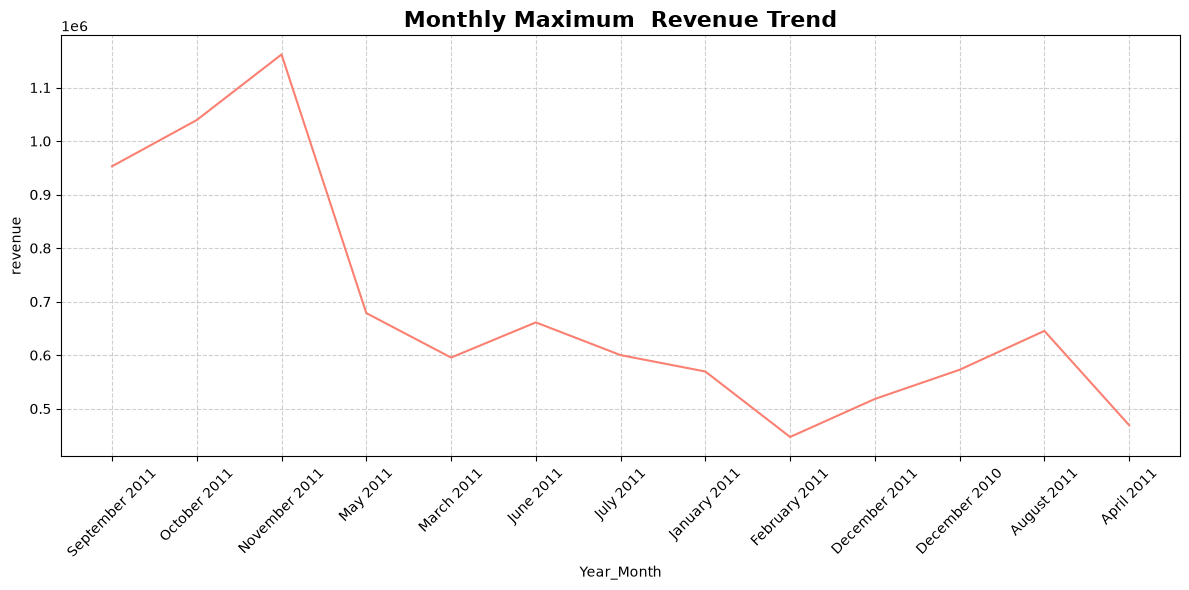

In [13]:
plt.figure(figsize=(12,6))

ax = sns.lineplot(
    data=df_max_time,
    x="Year_Month",
    y="revenue",
    color = "salmon"
   
)

plt.title(
    "Monthly Maximum  Revenue Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel= ("Year")
plt.ylabel=("Revenue ($)")

plt.xticks(rotation=45)

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

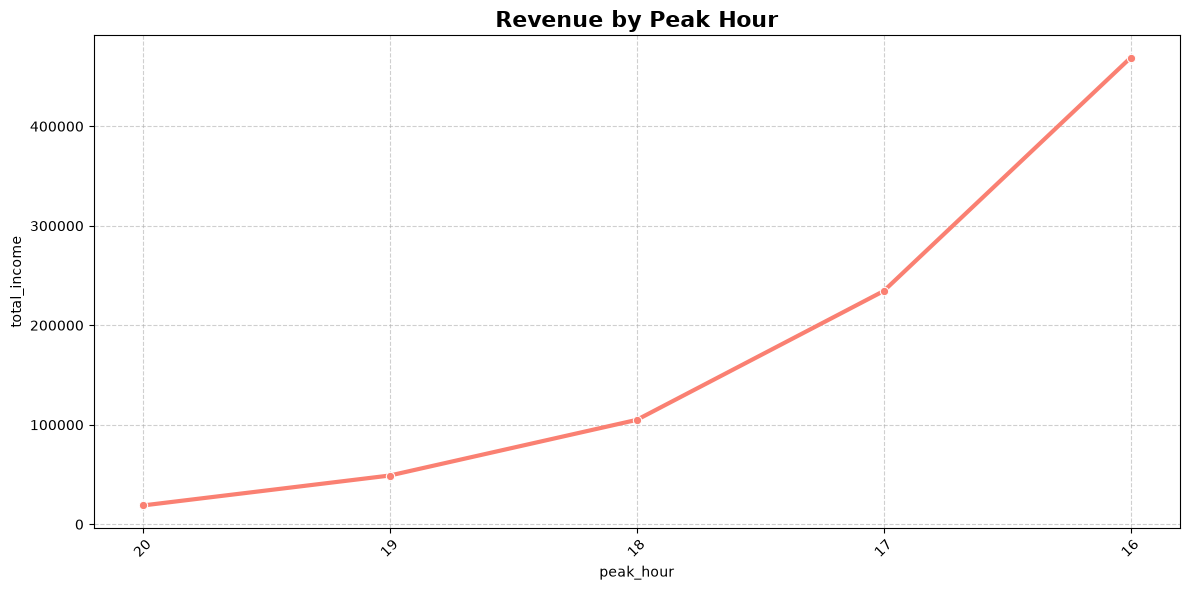

In [14]:
plt.figure(figsize=(12,6))

ax = sns.lineplot(
    data=df_max_hours,
    x="peak_hour",
    y="total_income",
    color="salmon",
    marker="o",
    linewidth=3
)

plt.title(
    "Revenue by Peak Hour",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel=("Peak Hour")
plt.ylabel=("Revenue ($)")

plt.xticks(rotation=45)

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

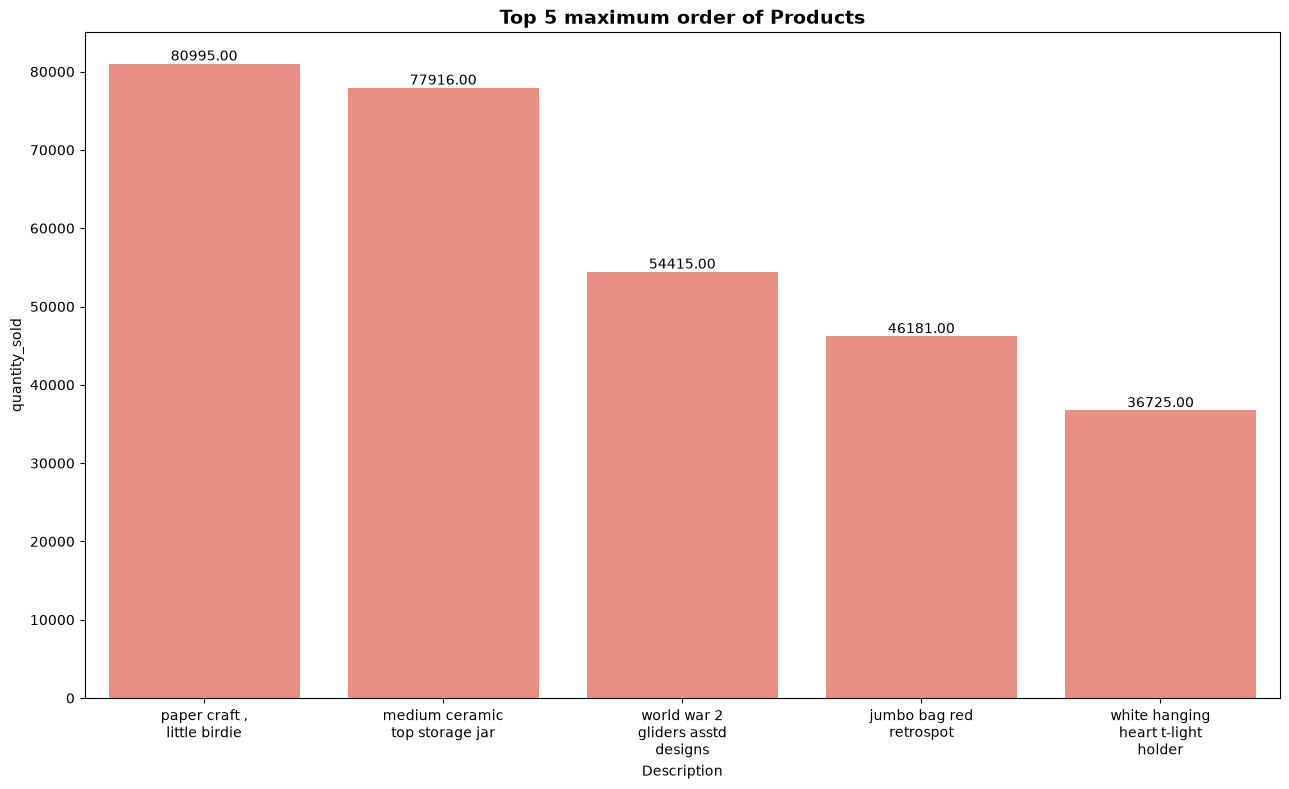

In [15]:


plt.figure(figsize=(13, 8))

ax = sns.barplot(
    data=df_max_products,
    x="Description",
    y="quantity_sold",
    color = "salmon"
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.title(
    "Top 5 maximum order of Products",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel=("Products")
plt.ylabel=("Quantity")

import textwrap

labels = [
    '\n'.join(textwrap.wrap(label, width=15))
    for label in df_max_products['Description']
]

plt.xticks(
    ticks=range(len(labels)),
    labels=labels,
    rotation=0
)
plt.savefig("top_products.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

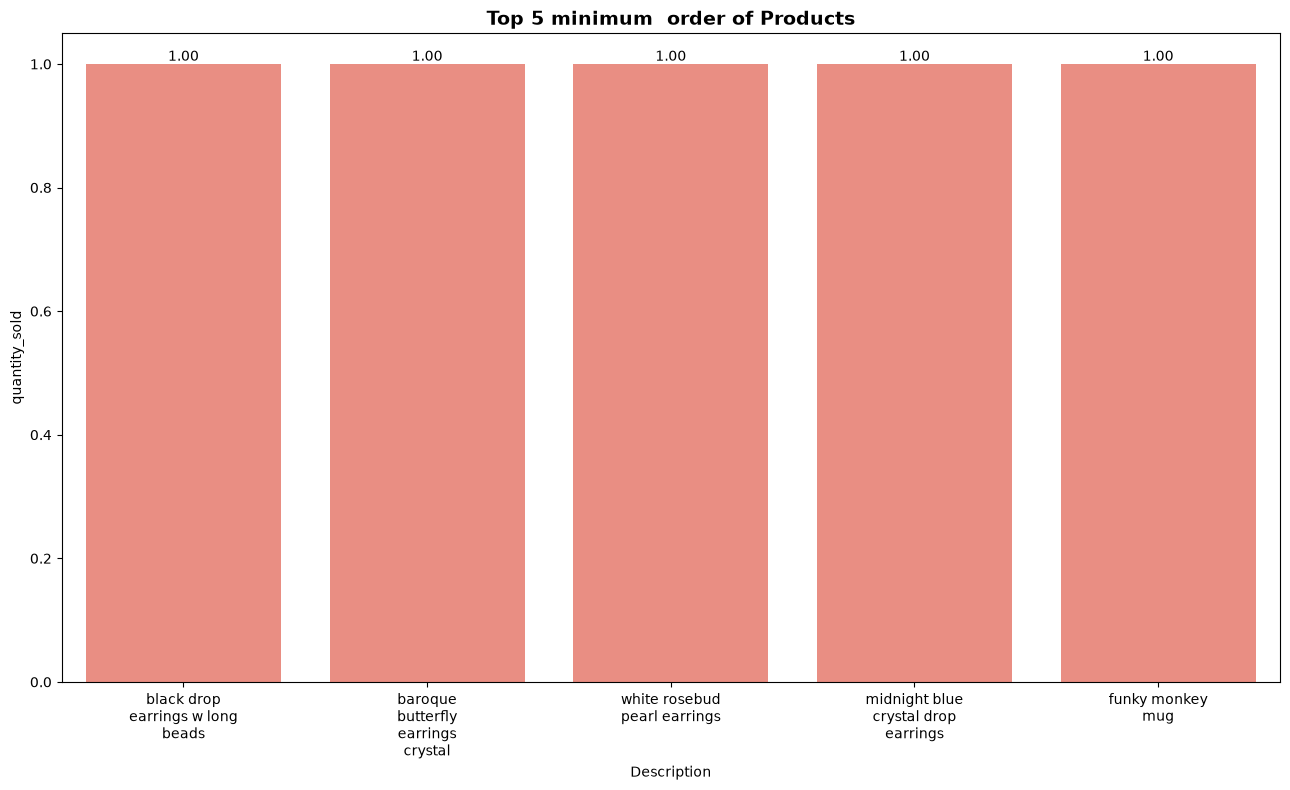

In [16]:




plt.figure(figsize=(13, 8))

ax = sns.barplot(
    data=df_min_products,
    x="Description",
    y="quantity_sold",
    color = "salmon"
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.title(
    "Top 5 minimum  order of Products",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel=("Products")
plt.ylabel=("Quantity")

import textwrap

labels = [
    '\n'.join(textwrap.wrap(label, width=15))
    for label in df_min_products['Description']
]

plt.xticks(
    ticks=range(len(labels)),
    labels=labels,
    rotation=0
)
plt.tight_layout()
plt.show()

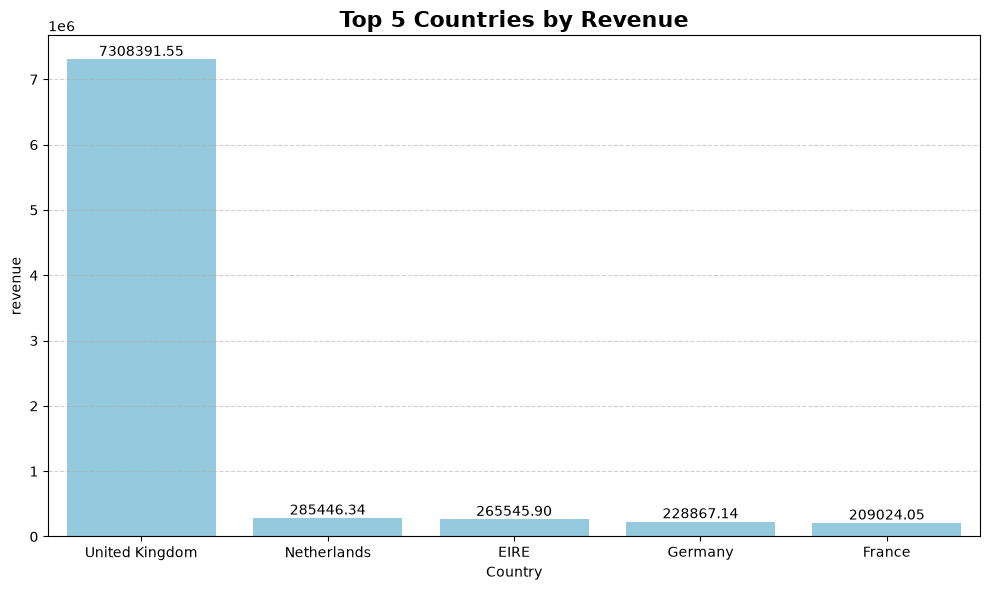

In [17]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=df_max_country,
    x="Country",
    y="revenue",
    color="skyblue"
)

plt.title(
    "Top 5 Countries by Revenue",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel=("Country")
plt.ylabel=("Revenue ($)")

# Add revenue labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

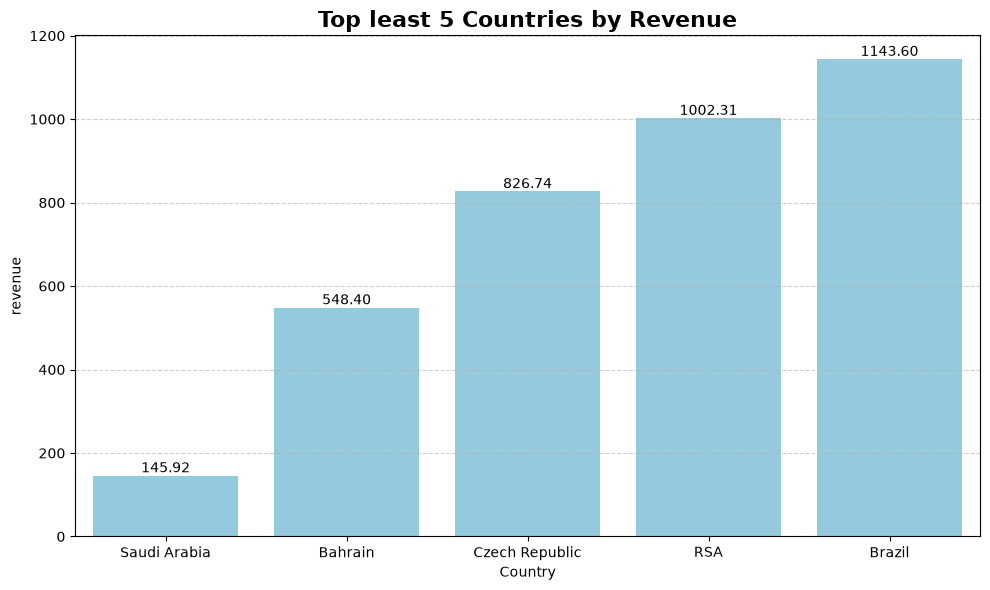

In [18]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=df_min_country,
    x="Country",
    y="revenue",
    color="skyblue"
)

plt.title(
    "Top least 5 Countries by Revenue",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel=("Country")
plt.ylabel=("Revenue ($)")

# Add revenue labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

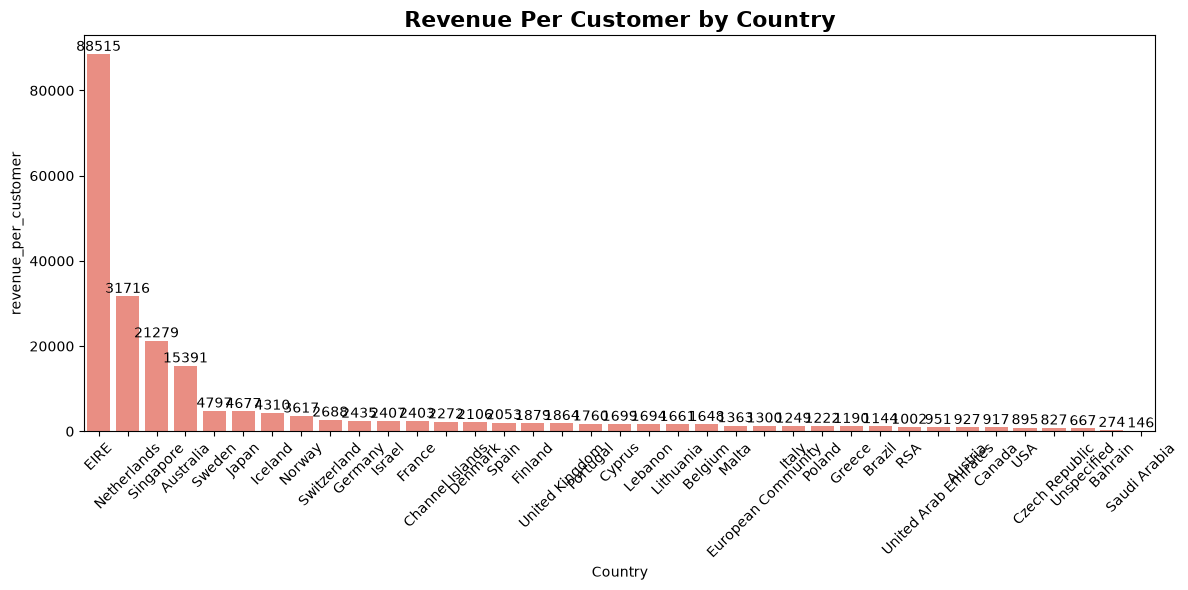

In [19]:
per_customer= pd.read_sql("""WITH country_stats AS (
    SELECT
        "Country",
        SUM("Total Price") AS total_revenue,
        COUNT(DISTINCT "CustomerID") AS total_customers
    FROM ecommerce
    GROUP BY "Country"
)

SELECT
    "Country",
    ROUND(total_revenue::numeric, 2) AS total_revenue,
    total_customers,

    ROUND(
        (total_revenue / total_customers)::numeric,
        2
    ) AS revenue_per_customer

FROM country_stats
ORDER BY revenue_per_customer DESC;  """, engine)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=per_customer,
    x="Country",
    y="revenue_per_customer",
    color="salmon"
)

plt.title(
    "Revenue Per Customer by Country",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel=("Country")
plt.ylabel=("Revenue Per Customer ($)")

plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.tight_layout()
plt.show()
